In [2]:
# ── CELL 1: MOUNT & INSTALL ────────────────────────────────────────────────────
#from google.colab import drive
#drive.mount('/content/drive', force_remount=True)
# !pip install statsmodels -q
#!pip install regex
#import regex as re

**Setup Cell**



---




In [3]:
# Specify body of text being used
statements=True; minutes=False; conferences=False; speeches=False

# Specify sentiment indicators being used (use same name as csv files in Taylor Rule Data folder)
Indicators = ['Gardner_statements_both_nlp']

# Specify regressors of interest (gap, inflation, and FFR are always included)
Regressors = ['inflation_dev_from_target','unemployment_gap','implied_ffr']



---



In [4]:
# ── CELL 2: IMPORTS & CONFIG ───────────────────────────────────────────────────
import os
import datetime
import pandas  as pd
import numpy   as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel

BASE_PATH  = '/content/drive/MyDrive/HEC Thesis/Taylor Rule Data/'
DATA_PATH  = '/content/drive/MyDrive/HEC Thesis/Data/'

# Input files
MACRO_FILE   = os.path.join(DATA_PATH,  'Master_Macro.csv')   # stacked dataset from pipeline
SHADOW_FILE  = os.path.join(BASE_PATH,  'Shadow_Rate.csv')
SENTIMENT_FILES = {i: os.path.join(f'{BASE_PATH}/NLP Output', f'{i}.csv') for i in Indicators}


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3: DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════

def load_macro(statements=True, minutes=False, conferences=False, speeches=False):
    HIERARCHY = [
        ('speeches',     'blackout_date'),
        ('minutes',      'minutes_date'),
        ('statements',   'meeting_date'),
        ('conferences',  'meeting_date'),
    ]
    flags = {
        'speeches':    speeches,
        'minutes':     minutes,
        'statements':  statements,
        'conferences': conferences,
    }
    selected_event = next(
        (event_col for name, event_col in HIERARCHY if flags[name]),
        None
    )
    if selected_event is None:
        raise ValueError("At least one event type must be True.")

    df = pd.read_csv(MACRO_FILE, parse_dates=['date'])
    df = df[df['event_type'] == selected_event].copy()
    df = df.sort_values('date').set_index('date')
    print(f"  ✓  Macro data: {len(df)} rows indexed to '{selected_event}'")
    return df


def load_shadow_rate():
    def parse_mmm_yy(s):
        try:
            dt = pd.to_datetime(s, format='%b-%y')
            if dt.year > datetime.datetime.now().year:
                dt = dt.replace(year=dt.year - 100)
            return dt
        except Exception:
            return pd.NaT

    df = pd.read_csv(SHADOW_FILE, sep=';', header=0, encoding='utf-8-sig')
    df = df.iloc[:, [0, 2]].copy()
    df.columns = ['date_raw', 'shadow_rate']
    df['shadow_rate'] = pd.to_numeric(df['shadow_rate'], errors='coerce')
    df['date']        = df['date_raw'].apply(parse_mmm_yy)
    df = (df.drop(columns=['date_raw'])
            .sort_values('date')
            .dropna(subset=['date', 'shadow_rate'])
            .drop_duplicates(subset='date'))
    print(f"  ✓  Shadow rate: {len(df)} rows  "
          f"[{df['shadow_rate'].min():.2f}, {df['shadow_rate'].max():.2f}]")
    return df


def load_sentiment(filepath, label):
    try:
        df = pd.read_csv(filepath)
        date_col = next((c for c in df.columns if c.lower() == 'date'), df.columns[0])
        df = df.rename(columns={date_col: 'date'})
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df = df.sort_values('date').dropna(subset=['date'])
        print(f"  ✓  {label}: {len(df)} rows")
        return df
    except Exception as e:
        print(f"  ✗  {label}: {e}")
        return pd.DataFrame(columns=['date'])

# ── Derived config ─────────────────────────────────────────────────────────────

multi_event  = sum([statements,minutes,conferences,speeches]) > 1
merge_kwargs = (
    dict(direction='nearest', tolerance=pd.Timedelta('2d'))
    if not multi_event else
    dict(direction='backward')
)

# ── Load everything ────────────────────────────────────────────────────────────
print("=== Loading data ===")
df_macro      = load_macro(statements,minutes,conferences,speeches)
df_shadow     = load_shadow_rate()
sentiment_dfs = {
    name: load_sentiment(path, name)
    for name, path in SENTIMENT_FILES.items()
}

# ── Merge shadow rate (match on Year-Month) ───────────────────────────────────
df_macro_reset            = df_macro.reset_index()
df_macro_reset['YYYY-MM'] = df_macro_reset['date'].dt.to_period('M')
df_shadow['YYYY-MM']      = df_shadow['date'].dt.to_period('M')
df_shadow_dedup           = df_shadow.drop_duplicates(subset='YYYY-MM', keep='last')

df_merged = pd.merge(
    df_macro_reset,
    df_shadow_dedup[['YYYY-MM', 'shadow_rate']],
    on='YYYY-MM', how='left'
).drop(columns=['YYYY-MM'])

# ── Merge sentiment indicators ────────────────────────────────────────────────
df_merged = df_merged.sort_values('date')
for name, df_sent in sentiment_dfs.items():
    keep_cols = ['date'] + [c for c in df_sent.columns if name.lower() in c.lower()]
    df_merged = pd.merge_asof(df_merged, df_sent[keep_cols],
                               on='date', **merge_kwargs)

# ── Set index & deduplicate ───────────────────────────────────────────────────
df_merged = df_merged.set_index('date')
df_merged = df_merged[~df_merged.index.duplicated(keep='first')]

# ── Effective rate: use shadow rate during ZLB (FFR ≤ 0.25%) ──────────────────
def get_effective_rate(row):
    sr  = row.get('shadow_rate',    np.nan)
    ffr = row.get('fed_funds_rate', np.nan)
    if pd.notna(sr) and pd.notna(ffr) and ffr <= 0.25:
        return sr
    return ffr

df_merged['effective_rate'] = df_merged.apply(get_effective_rate, axis=1)
df_merged['effective_rate'] = df_merged['effective_rate'].fillna(df_merged['fed_funds_rate'])

n_neg = (df_merged['effective_rate'] < 0).sum()
print(f"\n  Effective rate < 0 in {n_neg} periods (ZLB / post-ZLB periods)")

# ── Final dataset (2011 onwards) ──────────────────────────────────────────────
df_final = df_merged[df_merged.index >= '2011-01-01'].copy()
print(f"\n  df_final ready: {df_final.shape[0]} meetings × {df_final.shape[1]} columns")

# ── Sanity checks ─────────────────────────────────────────────────────────────
collision_cols = [c for c in df_merged.columns if c.endswith('_x') or c.endswith('_y')]
if collision_cols:
    print(f"\n  ⚠️  Column collisions detected: {collision_cols}")

=== Loading data ===
  ✓  Macro data: 121 rows indexed to 'meeting_date'
  ✓  Shadow rate: 386 rows  [-2.99, 8.14]
  ✓  Gardner_statements_both_nlp: 120 rows

  Effective rate < 0 in 50 periods (ZLB / post-ZLB periods)

  df_final ready: 121 meetings × 37 columns

  ⚠️  Column collisions detected: ['implied_ffr_x', 'implied_ffr_y']


## **Visualization**

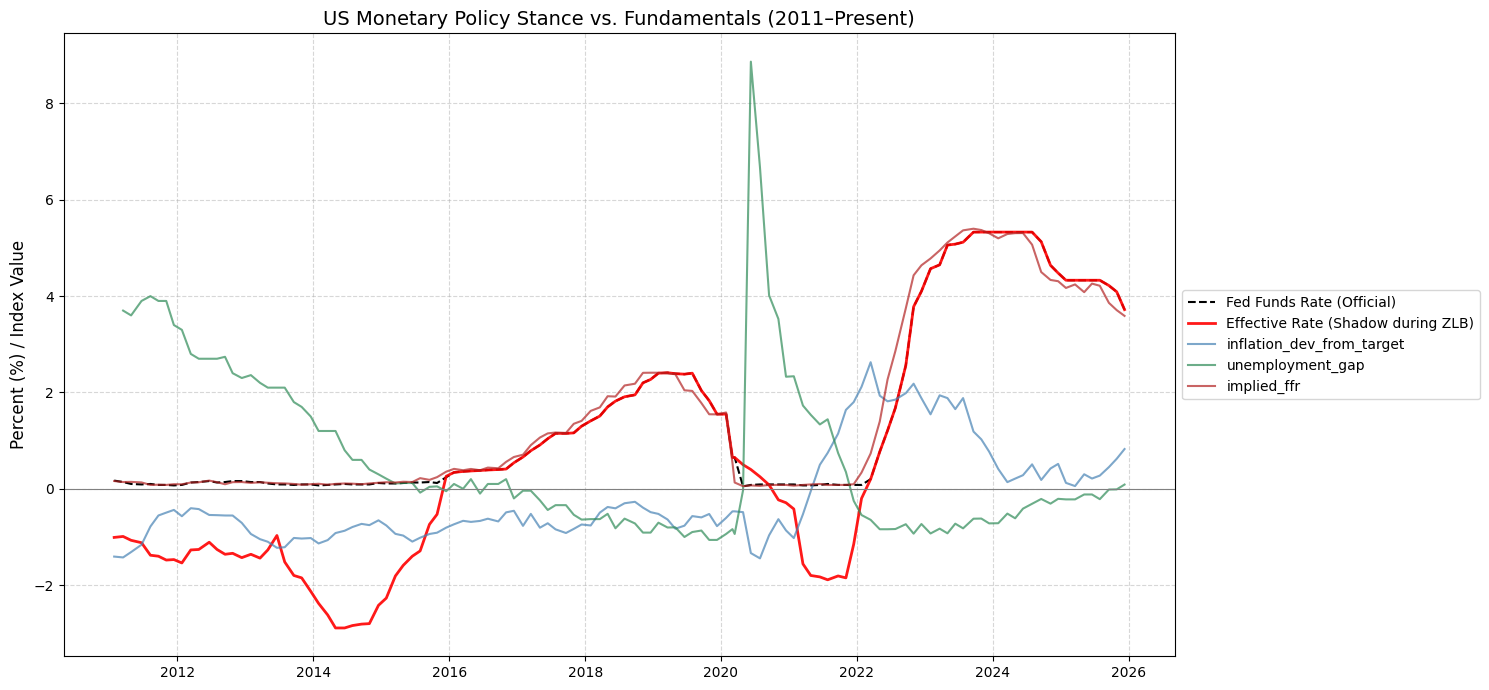

In [6]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4: VISUALIZATION
# ══════════════════════════════════════════════════════════════════════════════

# ── Colour cycle for dynamic series ───────────────────────────────────────────
COLORS = ['steelblue', 'seagreen', 'firebrick', 'darkorange',
          'purple', 'teal', 'saddlebrown', 'hotpink']

fig, ax = plt.subplots(figsize=(15, 7))

# ── Always plotted: policy rates ──────────────────────────────────────────────
ax.plot(df_final.index, df_final['fed_funds_rate'],
        label='Fed Funds Rate (Official)', color='black',
        linewidth=1.5, linestyle='--')
ax.plot(df_final.index, df_final['effective_rate'],
        label='Effective Rate (Shadow during ZLB)', color='red',
        linewidth=2, alpha=0.9)

# ── User-specified regressors ─────────────────────────────────────────────────
for i, col in enumerate(Regressors):
    if col in df_final.columns:
        ax.plot(df_final.index, df_final[col],
                label=col, color=COLORS[i % len(COLORS)],
                linewidth=1.5, alpha=0.7)
    else:
        print(f"  ⚠️  Regressor '{col}' not found in df_final — skipping")

# ── Sentiment indicators (generic loop over all loaded indicators) ────────────
linestyles = ['-', '--', '-.', ':']
for i, (name, df_sent) in enumerate(sentiment_dfs.items()):
    sent_cols = [c for c in df_final.columns if name.lower() in c.lower()]
    color     = COLORS[(len(Regressors) + i) % len(COLORS)]
    for j, col in enumerate(sent_cols):
        ax.plot(df_final.index, df_final[col],
                label=col, color=color,
                linewidth=1.2, alpha=0.7,
                linestyle=linestyles[j % len(linestyles)])

ax.axhline(0, color='grey', linewidth=0.8)
ax.set_title('US Monetary Policy Stance vs. Fundamentals (2011–Present)', fontsize=14)
ax.set_ylabel('Percent (%) / Index Value', fontsize=12)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
ax.grid(True, which='major', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5: POLICY DECISION CLASSIFICATION
# ══════════════════════════════════════════════════════════════════════════════

df_model = df_final.copy()
df_model['rate_change'] = df_model['effective_rate'].diff()

def classify_decision(change):
    if change > 0.01:    return  1   # hike
    elif change < -0.01: return -1   # cut
    else:                return  0   # hold

df_model['MPD'] = df_model['rate_change'].apply(classify_decision)

print("FOMC Decision distribution:")
print(df_model['MPD'].value_counts().rename({1: 'Hike', 0: 'Hold', -1: 'Cut'}))

FOMC Decision distribution:
MPD
Hike    62
Cut     42
Hold    17
Name: count, dtype: int64


# **OLS (endog = shadow rate, exog = Regressors)**

In [8]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6: OLS REGRESSION  (Taylor Rule augmented with sentiment)
# ══════════════════════════════════════════════════════════════════════════════

df_ols = df_model.copy()

# Target: next-meeting rate
df_ols['target_rate'] = df_ols['effective_rate'].shift(-1)

# ── Build predictors dynamically ──────────────────────────────────────────────
# Always included
base_predictors = ['effective_rate']

# Sentiment columns (all columns from each loaded indicator)
sentiment_predictors = [
    c for name in sentiment_dfs
    for c in df_final.columns
    if name.lower() in c.lower()
]

# User-specified regressors (from REGRESSORS in Cell 2)
PREDICTORS = base_predictors + sentiment_predictors + [
    r for r in Regressors if r not in base_predictors
]

print(f"  Predictors: {PREDICTORS}")

# ── Run OLS ───────────────────────────────────────────────────────────────────
df_clean   = df_ols[['target_rate'] + PREDICTORS].dropna()
y          = df_clean['target_rate']
X          = sm.add_constant(df_clean[PREDICTORS])
ols_result = sm.OLS(y, X).fit()
print(ols_result.summary())

  Predictors: ['effective_rate', 'inflation_dev_from_target', 'unemployment_gap', 'implied_ffr']
                            OLS Regression Results                            
Dep. Variable:            target_rate   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                     2950.
Date:                Thu, 05 Mar 2026   Prob (F-statistic):          4.61e-114
Time:                        12:32:34   Log-Likelihood:               -0.36025
No. Observations:                 119   AIC:                             10.72
Df Residuals:                     114   BIC:                             24.62
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------

# **Ordinal Probit (endog = Shadow rate, exog = Regressors):**



In [9]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7: ORDINAL PROBIT  (Hike / Hold / Cut)
# ══════════════════════════════════════════════════════════════════════════════

# ── Build predictors dynamically (same logic as OLS) ─────────────────────────
base_predictors = ['effective_rate']

sentiment_predictors = [
    c for name in sentiment_dfs
    for c in df_final.columns
    if name.lower() in c.lower()
]

ORDINAL_PREDICTORS = base_predictors + sentiment_predictors + [
    r for r in Regressors if r not in base_predictors
]

print(f"  Predictors: {ORDINAL_PREDICTORS}")

# ── Predict next meeting's decision ───────────────────────────────────────────
y_ord = df_model['MPD'].shift(-1).dropna()
X_ord = df_model[ORDINAL_PREDICTORS]

common_idx     = y_ord.index.intersection(X_ord.dropna().index)
y_ord          = y_ord.loc[common_idx]
X_ord          = X_ord.loc[common_idx]

ordinal_model  = OrderedModel(y_ord, X_ord, distr='probit')
ordinal_result = ordinal_model.fit(method='bfgs', disp=False)
print(ordinal_result.summary())

  Predictors: ['effective_rate', 'inflation_dev_from_target', 'unemployment_gap', 'implied_ffr']
                             OrderedModel Results                             
Dep. Variable:                    MPD   Log-Likelihood:                -96.474
Model:                   OrderedModel   AIC:                             204.9
Method:            Maximum Likelihood   BIC:                             221.6
Date:                Thu, 05 Mar 2026                                         
Time:                        12:32:34                                         
No. Observations:                 119                                         
Df Residuals:                     113                                         
Df Model:                           4                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
effe

# **Ordinal Probit (endog = Real rate, exog = Regressors):**


In [10]:
# @title
# ══════════════════════════════════════════════════════════════════════════════
# CELL 8: ORDINAL PROBIT  (Hike / Hold / Cut) using actual FFR
# ══════════════════════════════════════════════════════════════════════════════

df_model['rate_change_actual'] = df_model['fed_funds_rate'].diff()

def classify_decision(change):
    if change > 0.01:    return  1   # hike
    elif change < -0.01: return -1   # cut
    else:                return  0   # hold

df_model['MPD_actual'] = df_model['rate_change_actual'].apply(classify_decision)

print("FOMC Actual Decision distribution:")
print(df_model['MPD_actual'].value_counts().rename({1: 'Hike', 0: 'Hold', -1: 'Cut'}))


# ── Build predictors dynamically (same logic as OLS) ─────────────────────────
base_predictors = [ 'MPD_actual']

sentiment_predictors = [
    c for name in sentiment_dfs
    for c in df_final.columns
    if name.lower() in c.lower()
]

ORDINAL_PREDICTORS = base_predictors + sentiment_predictors + [
    r for r in Regressors if r not in base_predictors
]

print(f"  Predictors: {ORDINAL_PREDICTORS}")

# ── Predict next meeting's decision ───────────────────────────────────────────
y_ord = df_model['MPD_actual'].shift(-1).dropna()
X_ord = df_model[ORDINAL_PREDICTORS]

common_idx     = y_ord.index.intersection(X_ord.dropna().index)
y_ord          = y_ord.loc[common_idx]
X_ord          = X_ord.loc[common_idx]

ordinal_model  = OrderedModel(y_ord, X_ord, distr='probit')
ordinal_result = ordinal_model.fit(method='bfgs', disp=False)
print(ordinal_result.summary())

FOMC Actual Decision distribution:
MPD_actual
Hike    51
Hold    43
Cut     27
Name: count, dtype: int64
  Predictors: ['MPD_actual', 'inflation_dev_from_target', 'unemployment_gap', 'implied_ffr']
                             OrderedModel Results                             
Dep. Variable:             MPD_actual   Log-Likelihood:                -110.02
Model:                   OrderedModel   AIC:                             232.0
Method:            Maximum Likelihood   BIC:                             248.7
Date:                Thu, 05 Mar 2026                                         
Time:                        12:32:35                                         
No. Observations:                 119                                         
Df Residuals:                     113                                         
Df Model:                           4                                         
                                coef    std err          z      P>|z|      [0.025      0.97

# **Walk Forward Cross Validation**

In [11]:
# We will store the sharpes of each alpha
sharpes = pd.Series(dtype=float)

for alpha in np.logspace(-7, -4, 15):

    # Recompute the model every month, skip the first 2 months
    rebalancing_dates = pd.date_range(
        start=start_date_train,
        end=last_date_train,
        freq="ME"
    )[2:]

    # Predictions made over successive validation sets will be aggregated into a DataFrame
    predictions = pd.DataFrame(
        0,
        index=data["return"].index,
        columns=data["return"].columns,
    )

    # Launch the training loop
    for last_date_train_fold in rebalancing_dates:

        # Define training and validation dates

        # Train the model over the last 12 months
        start_date_train_fold = last_date_train_fold - pd.Timedelta(days = 31 * 12)

        # The model cannot be used before the first hour following the training
        # (no look-forward bias)
        start_date_validate_fold = last_date_train_fold + pd.Timedelta(hours = 1)

        # The trained model will be used for 1 month
        last_date_validate_fold = last_date_train_fold + pd.Timedelta(days = 31 * 1)

        # Log informations
        print(f"Train a model from date {start_date_train_fold} to date {last_date_train_fold}")
        print(f"Predict from date {start_date_validate_fold} to date {last_date_validate_fold}")
        print("")

        # Create label
        label_fold = data["return"].loc[start_date_train_fold:last_date_train_fold
            ].shift(-1).stack()

        # Only keep dates of the train and validation sets for the features
        features_normalized_train_fold = features_normalized.reindex(label_fold.index).fillna(0)
        features_normalized_validate_fold = features_normalized.sort_index().loc[
            start_date_validate_fold:last_date_validate_fold]

        # Define the model
        model = sklearn.linear_model.ElasticNet(
            alpha=alpha,
            l1_ratio=1,
            fit_intercept=True,
            tol=2e-2,
            selection="random",
            max_iter=500,
        )

        # Fit model
        model = model.fit(
            y=label_fold,
            X=features_normalized_train_fold,
        )

        # Predict on the validation set
        predictions_fold = model.predict(
            features_normalized_validate_fold)
        predictions_fold = pd.Series(
            predictions_fold,
            index=features_normalized_validate_fold.index
        ).unstack()

        # Aggregate with other predictions
        predictions.loc[start_date_validate_fold:last_date_validate_fold] = predictions_fold

    # Remove extra zeros added in the process, as we don't want to take positions
    # if there was no prediction
    predictions = predictions.replace(0, np.nan)

    # Remove empty and invalide dates
    predictions = predictions.dropna(axis=0, how='all').loc[
        start_date_train:last_date_train]

    # Analyse our predictions
    sharpes.loc[alpha] = analyze_expected_returns(
        expected_returns=predictions,
        returns=data["return"].loc[predictions.index],
        rfr_hourly=rfr_hourly,
        title=f"Regularized Elastic Net model, lambda={alpha} Training Set",
        lags=[0,1,2,3,6,12],
        tc=tc,
        output_stats=True,
    )["sharpe"].iloc[0]

# Select the optimal alpha
#optimal_alpha = sharpes.idxmax()


NameError: name 'start_date_train' is not defined